In [12]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model import CANN_DDM_model
from tqdm import tqdm
import pickle
import seaborn as sns
import json
import matplotlib.ticker as mticker

import matplotlib.lines as mlines

In [13]:
with open('../results/model_config_default.json') as data:
    CANN_params = json.load(data)
    decision_space_params = CANN_params['decision_space_params']
    edge_pop = CANN_params['edge_pop']
    bump_pop = CANN_params['bump_pop']
    



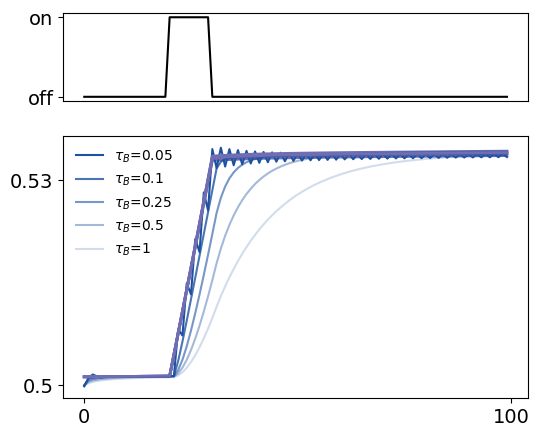

In [24]:
fig, ax = plt.subplots(2, figsize=(6, 5), gridspec_kw={'height_ratios': [1, 3]})

ax[0].plot(model.cue_R_all[t_start:t_start+dur], color='black', label='right')
#ax[0].plot(model.cue_L_all[t_start:t_start+dur], color='black', label='left')
ax[0].set_xticks([])
ax[0].set_yticks([0,1], ['off', 'on'], fontsize=14)
#ax[0].legend()
for i in range(len(x_B_all)):
    ax[1].plot(x_E_all[i][t_start:t_start+dur], color=bump_color, linewidth=2)
    ax[1].plot(x_B_all[i][t_start:t_start+dur], color=edge_color, alpha = 1-i/len(x_B_all), label=r'$\tau_B$=' + str(tau_B_all[i]))

#ax[1].set_xlabel('Time [ms]', fontsize=16)
ax[1].set_xticks([0, 100], [0, 100], fontsize=14)
ax[1].set_yticks([0.50, 0.53], [0.5, 0.53], fontsize=14)
ax[1].legend(frameon=False)


Predict 1100 steps: : 100%|██████████| 1100/1100 [00:01<00:00, 1016.93it/s]


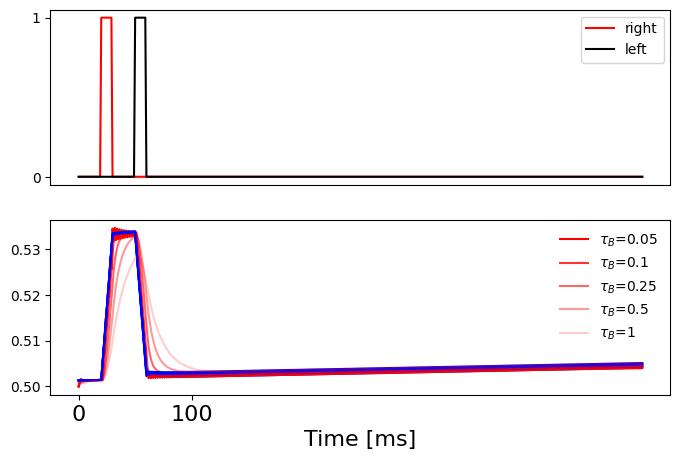

In [13]:
pos_offset = 0.03
t_start = decision_space_params['t_start']
t_sim = int(decision_space_params['dur1'] + decision_space_params['dur2'])
t1 = 20
t2 = 30
t3 = 50
t4 = 60
dur = 500

x_B_all = []
x_E_all = []
tau_B_all = [0.05, 0.1, 0.25, 0.5, 1]
for tau_B in tau_B_all:
    #edge_pop.update({'tau_E': tau_E})
    bump_pop.update({'tau_B': tau_B})
    #CANN_params.update({'edge_pop': edge_pop})
    CANN_params.update({'bump_pop': bump_pop})
    model = CANN_DDM_model(CANN_params = CANN_params)
    cue_R_all = np.zeros(t_sim)
    cue_L_all = np.zeros(t_sim)
    cue_R_all[t_start+t1:t_start+t2] = 1
    cue_L_all[t_start+t3:t_start+t4] = 1
    model.cue_R_all = cue_R_all
    model.cue_L_all = cue_L_all
    mon_vars = ['hit_boundary', 'x_B', 'x_E']
    runner, RT = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)
    x_B_all.append(runner.mon.x_B)
    x_E_all.append(runner.mon.x_E)


fig, ax = plt.subplots(2, figsize=(8, 5))

ax[0].plot(model.cue_R_all[t_start:t_start+dur], color='red', label='right')
ax[0].plot(model.cue_L_all[t_start:t_start+dur], color='black', label='left')
ax[0].set_xticks([])
ax[0].set_yticks([0,1])
for i in range(len(x_B_all)):
    ax[1].plot(x_E_all[i][t_start:t_start+dur], color='blue')
    ax[1].plot(x_B_all[i][t_start:t_start+dur], color='red', alpha = 1-i/len(x_B_all), label=r'$\tau_B$=' + str(tau_B_all[i]))
ax[0].legend()
ax[1].set_xlabel('Time [ms]', fontsize=16)
ax[1].set_xticks([0, 100], [0, 100], fontsize=16)
ax[1].legend(frameon=False)

In [4]:
pos_offset = 0.03
t_start = decision_space_params['t_start']
t_sim = int(decision_space_params['dur1'] + decision_space_params['dur2'])
t1 = 20
t2 = 30
t3 = 50
t4 = 60
dur = 100

x_B_all = []
x_E_all = []

tau_E_all = [0.25, 0.5, 1, 2]
tau_B = 0.1
for tau_E in tau_E_all:
    edge_pop.update({'tau_E': tau_E})
    bump_pop.update({'tau_B': tau_B})
    #CANN_params.update({'edge_pop': edge_pop})
    CANN_params.update({'bump_pop': bump_pop, 'edge_pop': edge_pop})
    model = CANN_DDM_model(CANN_params = CANN_params)
    cue_R_all = np.zeros(t_sim)
    cue_L_all = np.zeros(t_sim)
    cue_R_all[t_start+t1:t_start+t2] = 1
    cue_L_all[t_start+t3:t_start+t4] = 1
    model.cue_R_all = cue_R_all
    model.cue_L_all = cue_L_all
    mon_vars = ['hit_boundary', 'x_B', 'x_E']
    runner, RT = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)
    x_B_all.append(runner.mon.x_B)
    x_E_all.append(runner.mon.x_E)

Predict 1100 steps: : 100%|██████████| 1100/1100 [00:00<00:00, 1352.29it/s]


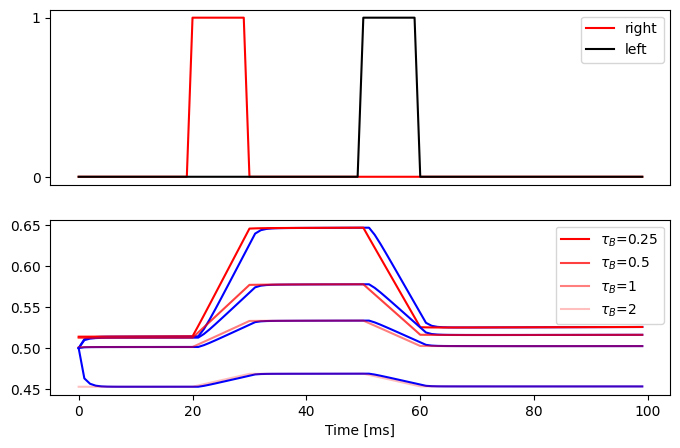

In [10]:
fig, ax = plt.subplots(2, figsize=(8, 5))

ax[0].plot(model.cue_R_all[t_start:t_start+dur], color='red', label='right')
ax[0].plot(model.cue_L_all[t_start:t_start+dur], color='black', label='left')
ax[0].set_xticks([])
ax[0].set_yticks([0,1])
for i in range(len(x_E_all)):
    ax[1].plot(x_B_all[i][t_start:t_start+dur], color='blue')
    ax[1].plot(x_E_all[i][t_start:t_start+dur], color='red', alpha = 1-i/len(x_E_all), label=r'$\tau_B$=' + str(tau_E_all[i]))
ax[0].legend()
ax[1].set_xlabel('Time [ms]')
ax[1].legend()